In [2]:
from PIL import Image, ImageDraw
from typing import List, Dict
from copy import deepcopy
from pathlib import Path
import os
import io
import glob
import json
import base64
import argparse
import numpy as np


def format_box(boxes):
    # Hyperparameter
    PRECISION = 3
    
    box_strs = []
    for box in boxes:
        box_strs.append(','.join([f"{elem:.{PRECISION}f}" for elem in box]))
    box_str = ';'.join(box_strs)
    # if self.use_small_brackets:
    #     return "(" + box_str + ")"
    return "[" + box_str + "]"

def read_json(json_file):
    with open(json_file, "r") as f:
        json_data = json.load(f)
    return json_data

def read_jsonl(jsonl_file):
    with open(jsonl_file, "r") as f:
        lines = [json.loads(line.rstrip()) for line in f.readlines()]
    return lines

def read_lines(txt_file):
    with open(txt_file, "r") as f:
        lines = [line.rstrip() for line in f.readlines()]
    return lines

def write_json(json_data, save_path):
    with open(save_path, "w") as f:
        json.dump(json_data, f)

def write_jsonl(lines, save_path):
    with open(save_path, "w") as f:
        for line in lines:
            json_record = json.dumps(line)
            f.write(json_record + '\n')

def image_to_base64(image_path, box=None):
    # Open the image file
    with Image.open(image_path) as image:
        # Convert the image to RGB format if it's not
        if image.mode != 'RGB':
            image = image.convert('RGB')
        if box is not None:
            draw = ImageDraw.Draw(image)
            draw.rectangle(box, outline=(0,255,0), width=3)
        # Save the image into a bytes buffer
        buffered = io.BytesIO()
        image.save(buffered, format="JPEG")
        # Encode the bytes as base64
        img_str = base64.b64encode(buffered.getvalue())
        return img_str.decode('utf-8')




def expand2square(pil_img, background_color):
    width, height = pil_img.size
    if width == height:
        return pil_img
    elif width > height:
        result = Image.new(pil_img.mode, (width, width), background_color)
        result.paste(pil_img, (0, (width - height) // 2))
        return result
    else:
        result = Image.new(pil_img.mode, (height, height), background_color)
        result.paste(pil_img, ((height - width) // 2, 0))
        return result




# Function to generate an HTML file with visualization results given the LLaVA-format annotation
def generate_html_file(
    data_dicts: List[Dict],
    model,
    tokenizer,
    save_path: str,
    idxs: List[int] = None,
):

    num_data = len(data_dicts)

    if idxs is None:
        idxs = list(np.arange(min(10, num_data)))

    print(f"Visualize {len(idxs)} from {num_data} images.")

    with open(save_path, 'w') as html_file:
        html_file.write('<html><head><title>Visualization Results</title></head><body>')

        # Add header row
        html_file.write('<div style="display: flex; font-weight: bold; text-align:center;">')
        html_file.write('<div style="flex: 1;">Index</div>')
        html_file.write('<div style="flex: 1;">Image</div>')
        html_file.write('<div style="flex: 1;">Expr</div>')
        html_file.write('<div style="flex: 1;">Ground truth</div>')
        html_file.write('<div style="flex: 1;">Prediction</div>')
        html_file.write('</div><br>')

        for idx in idxs:
            if idx >= num_data:
                raise Warning(f"Invalid index: {idx}")
                continue
            item = data_dicts[idx]
            image_path = f"/dataset/coco/train2014/{item['img_path']}"
            image_in_base64 = image_to_base64(image_path, item['bbox'])
            
            gt_path = f"/dataset/ref3_val/refcoco/{item['mask_path']}"
            gt_in_base64 = image_to_base64(gt_path, item['bbox'])

            expr = item['expression']
            conversation_str = f"{expr}<br>"
            
            with torch.no_grad():
                image = Image.open(image_path).convert('RGB')
                image = expand2square(image, tuple(int(x*255) for x in model.vision_encoder.image_processor.image_mean))
                image = model.vision_encoder.image_processor(image, return_tensors='pt')['pixel_values'][0][None].cuda()

                target = torch.from_numpy(np.array(Image.open(gt_path))).float()[None,None].cuda()
                
                encoded_text = qformer_tokenizer(
                    text=expr,
                    add_special_tokens=False,
                    padding=True,
                    return_special_tokens_mask=False,
                    return_offsets_mapping=False,
                    return_token_type_ids=False,
                    return_length=False,
                    return_tensors='pt',
                )
        
                inputs = dict(
                    pixel_values=image,
                    qformer_input_ids=encoded_text['input_ids'].cuda(),
                    qformer_attention_mask=encoded_text['attention_mask'].cuda(),
                    targets=[target],
                )

                pred_mask = (model(**inputs)[0]['pred_mask'] > 0).detach().cpu().numpy()
                pred_mask = Image.fromarray( pred_mask[0,0] ).convert('RGB')
                draw = ImageDraw.Draw(pred_mask)
                draw.rectangle(item['bbox'], outline=(0,255,0), width=3)
                # Save the image into a bytes buffer
                pred_mask_buffered = io.BytesIO()
                pred_mask.save(pred_mask_buffered, format="JPEG")
                # Encode the bytes as base64
                pred_in_base64 = base64.b64encode(pred_mask_buffered.getvalue()).decode('utf-8')


            # Create a row for each quadruplet with four columns
            html_file.write('<div style="display: flex; align-items:center;">')

            # Display ID in the 1st column
            html_file.write(f'<div style="flex: 1; text-align:center;">{idx}</div>')

            # Display image in the 2nd column
            html_file.write(f'<div style="flex: 1;"><img src="data:image/jpeg;base64,{image_in_base64}" alt="Embedded Image" width="200"></div>')
            
            # Display question in the 3rd column
            html_file.write(f'<div style="flex: 1;">{conversation_str}</div>')
            
            # Display gt in the 4th column
            html_file.write(f'<div style="flex: 1;"><img src="data:image/jpeg;base64,{gt_in_base64}" alt="Embedded Image" width="200"></div>')
            
            # Display pred in the 5th column
            html_file.write(f'<div style="flex: 1;"><img src="data:image/jpeg;base64,{pred_in_base64}" alt="Embedded Image" width="200"></div>')

            html_file.write('</div><br>')

        html_file.write('</body></html>')

In [3]:
parser = argparse.ArgumentParser(description='Generate HTML visualization file from JSONL data.')
parser.add_argument('--output-dir', '--output_dir', default="./vis_html/", help='Path to dir to save output')
args = parser.parse_args(args=[])

if not os.path.exists(args.output_dir):
    os.makedirs(args.output_dir, exist_ok=True)

json_data = read_jsonl('/dataset/RIS_refcoco_val.jsonl')

In [4]:
from transformers import AutoTokenizer
from tqdm import tqdm
import torch

from custom_model.builder import base_1456, base_1456_bef


qformer_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased", truncation_side="left")
qformer_tokenizer.add_special_tokens({"bos_token": "[DEC]"})

# seed = 42
# torch.manual_seed(seed)

# model = base_1456().cuda()
model = base_1456_bef().cuda()

# model_name = 'init'
# model_name = 'base-ep1-bs64-lr1e-5-wd3e-2'
# model_name = 'base-ep3-bs16-lr1e-5-wd3e-2'
# model_name = 'base-ep3-bs16-lr1e-5-wd3e-2-refcoco'
# model_name = 'base-ep20-bs64-lr1e-4-wd1e-2-refcoco'
# model_name = 'base-ep40-bs32-lr5e-5-wd1e-2-refcoco'
# model_name = 'base-ep20-bs16-lr5e-5-wd1e-2'
model_name = 'base-ep20-bs64-lr1e-4-wd1e-2-Abefv2'

ckpt = torch.load(f'./checkpoints/{model_name}/pytorch_model.pt', map_location='cpu')
missing, unexpected = model.load_state_dict(ckpt, strict=False)
print(len(missing), missing)       ## 391 or 392 ##
print(len(unexpected), unexpected) ## 0          ##
model.eval()



generate_html_file(
    json_data,
    model,
    qformer_tokenizer,
    Path(args.output_dir) / f"{model_name}.html",
    [1, 5, 10, 15, 20, 25, 50]
)

/home/oym/miniconda3/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2024-04-09 12:16:47,138] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/oym/miniconda3/envs/llava/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


391 ['vision_encoder.vision_tower.vision_model.embeddings.class_embedding', 'vision_encoder.vision_tower.vision_model.embeddings.patch_embedding.weight', 'vision_encoder.vision_tower.vision_model.embeddings.position_embedding.weight', 'vision_encoder.vision_tower.vision_model.pre_layrnorm.weight', 'vision_encoder.vision_tower.vision_model.pre_layrnorm.bias', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.k_proj.weight', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.k_proj.bias', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj.weight', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj.bias', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj.weight', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.q_proj.bias', 'vision_encoder.vision_tower.vision_model.encoder.layers.0.self_attn.out_proj.weight', 'vision_encoder.vision_tower.vision_model.encode

CustomModel(
  (vision_encoder): CLIPVisionTower(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
           

In [5]:
pil_image = Image.open('/home/oym/asdf.jpg').convert('RGB')
orig_w, orig_h = pil_image.size
image = expand2square(pil_image, tuple(int(x*255) for x in model.vision_encoder.image_processor.image_mean))
image = model.vision_encoder.image_processor(image, return_tensors='pt')['pixel_values'][0][None].cuda()

# expr = 'the guy wearing a white shirt'
expr = 'the upside down person'
# expr = 'the air conditioner'

encoded_text = qformer_tokenizer(
    text=expr,
    add_special_tokens=False,
    padding=True,
    return_special_tokens_mask=False,
    return_offsets_mapping=False,
    return_token_type_ids=False,
    return_length=False,
    return_tensors='pt',
)

inputs = dict(
    pixel_values=image,
    qformer_input_ids=encoded_text['input_ids'].cuda(),
    qformer_attention_mask=encoded_text['attention_mask'].cuda(),
)

In [6]:
with torch.no_grad():
    model.eval()
    outputs = model(**inputs)
    pred_mask = model.postprocess_masks(outputs[0], (orig_h, orig_w))
    pred_mask = (pred_mask > 0).detach().cpu().numpy()
    pred_mask = Image.fromarray( pred_mask[0,0] ).convert('RGB')

the guy wearing a white shirt


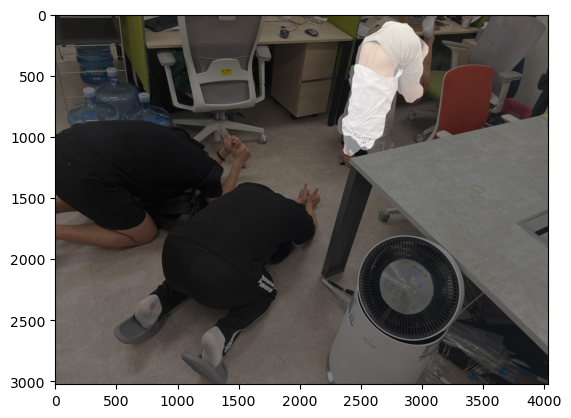

In [39]:
import matplotlib.pyplot as plt
plt.imshow(pil_image)
plt.imshow(pred_mask, alpha=0.5)
print(expr)

the upside down person


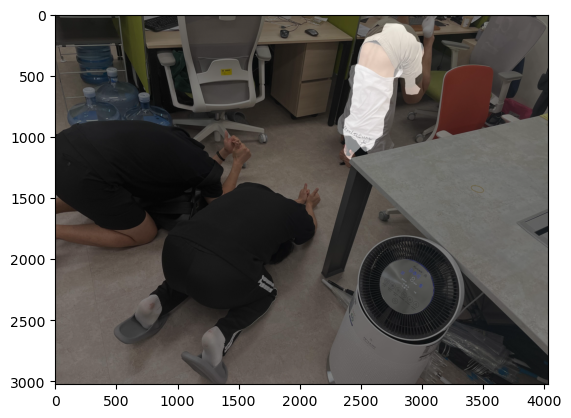

In [7]:
import matplotlib.pyplot as plt
plt.imshow(pil_image)
plt.imshow(pred_mask, alpha=0.5)
print(expr)

the air conditioner


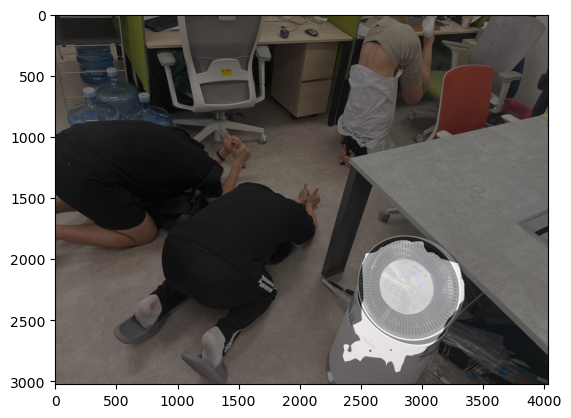

In [42]:
import matplotlib.pyplot as plt
plt.imshow(pil_image)
plt.imshow(pred_mask, alpha=0.5)
print(expr)